<a href="https://colab.research.google.com/github/tarannump096-cpu/ANN/blob/main/Mushroom_dataset_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install pandas numpy matplotlib scikit-learn tensorflow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [8]:
df = pd.read_csv("/content/primary_data.csv", sep=';', on_bad_lines='skip')

print(df.head())

           family               name class cap-diameter cap-shape Cap-surface  \
0  Amanita Family         Fly Agaric     p     [10, 20]    [x, f]      [g, h]   
1  Amanita Family        Panther Cap     p      [5, 10]    [p, x]         [g]   
2  Amanita Family  False Panther Cap     p     [10, 15]    [x, f]         NaN   
3  Amanita Family        The Blusher     e      [5, 15]    [x, f]         NaN   
4  Amanita Family          Death Cap     p      [5, 12]    [x, f]         [h]   

  cap-color does-bruise-or-bleed gill-attachment gill-spacing  ... stem-root  \
0    [e, o]                  [f]             [e]          NaN  ...       [s]   
1       [n]                  [f]             [e]          NaN  ...       NaN   
2    [g, n]                  [f]             [e]          NaN  ...       NaN   
3       [n]                  [t]             NaN          NaN  ...       [b]   
4       [r]                  [f]             NaN          [c]  ...       NaN   

  stem-surface stem-color veil-t

In [9]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(173, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   family                173 non-null    object
 1   name                  173 non-null    object
 2   class                 173 non-null    object
 3   cap-diameter          173 non-null    object
 4   cap-shape             173 non-null    object
 5   Cap-surface           133 non-null    object
 6   cap-color             173 non-null    object
 7   does-bruise-or-bleed  173 non-null    object
 8   gill-attachment       145 non-null    object
 9   gill-spacing          102 non-null    object
 10  gill-color            173 non-null    object
 11  stem-height           173 non-null    object
 12  stem-width            173 non-null    object
 13  stem-root             27 non-null     object
 14  stem-surface          65 non-null     object
 15  stem-color            173 non-

In [10]:
label_encoder = LabelEncoder()

for column in df.columns:
    df[column] = label_encoder.fit_transform(df[column])

In [11]:
X = df.drop('class', axis=1)

y = df['class']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.4182 - loss: 0.7761 - val_accuracy: 0.5357 - val_loss: 0.7179
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4727 - loss: 0.7303 - val_accuracy: 0.4643 - val_loss: 0.6894
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.7014 - val_accuracy: 0.6071 - val_loss: 0.6746
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5545 - loss: 0.6791 - val_accuracy: 0.5714 - val_loss: 0.6676
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5818 - loss: 0.6619 - val_accuracy: 0.5000 - val_loss: 0.6621
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6000 - loss: 0.6496 - val_accuracy: 0.5000 - val_loss: 0.6586
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6182 - loss: 0.6368 - val_accuracy: 0.5714 - val_loss: 0.6555
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6364 - loss: 0.6253 - val_accuracy: 0.6071 - val_loss: 0.65

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3429 - loss: 0.8021
Accuracy: 0.34285715222358704


In [18]:
prediction = model.predict(X_test[:5])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.48523244]
 [0.863773  ]
 [0.4942313 ]
 [0.65584326]
 [0.53482807]]


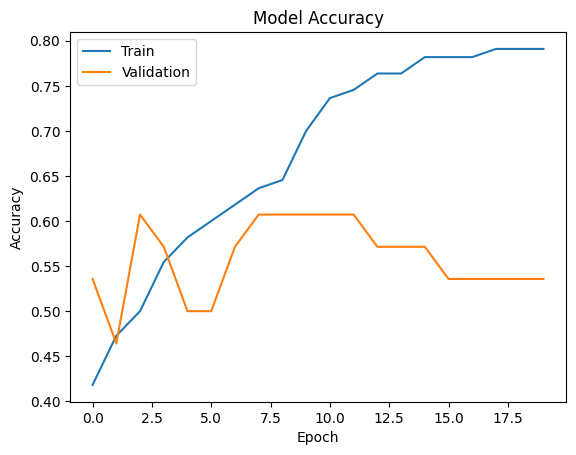

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

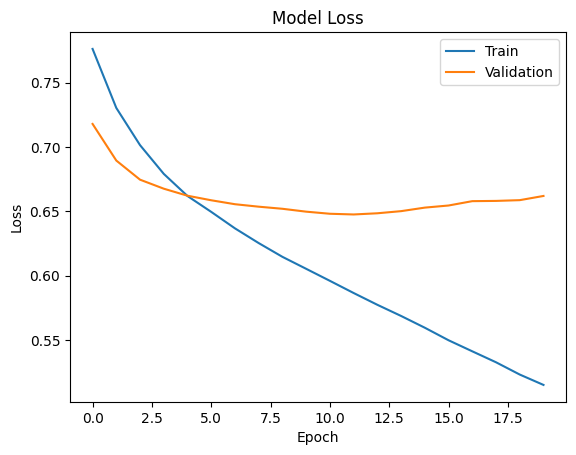

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [21]:
model.save("mushroom_ann_model.h5")